In [209]:
#NOT USED

from os import listdir, makedirs
from os.path import isfile, isdir, join

import numpy as np
import pandas as pd

def get_aia_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter='\t', parse_dates=True)
    df['end_time'] = fix_timestamps(df['end_time'], format='%Y-%m-%dT%H:%M:%S')
    df['start_time'] = fix_timestamps(df['start_time'], format='%Y-%m-%dT%H:%M:%S')
    df['peak_time'] = fix_timestamps(df['peak_time'], format='%Y-%m-%dT%H:%M:%S')
    return df

def get_goes_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter='\t', parse_dates=True)
    df['end_time'] = fix_timestamps(df['end_time'], format='%Y-%m-%d %H:%M:%S')
    df['start_time'] = fix_timestamps(df['start_time'], format='%Y-%m-%d %H:%M:%S')
    df['peak_time'] = fix_timestamps(df['peak_time'], format='%Y-%m-%d %H:%M:%S')
    return df


def fix_timestamps(ds, format=None):
    if format is None:
        ds_fixed = pd.to_datetime(ds, format="%Y%m%d_%H%M%S")
    else:
        ds_fixed = pd.to_datetime(ds, format=format)
    return ds_fixed

def remove_duplicates_from_goes_flares(goes_df):
    # remove all totally duplicated rows from goes df
    duplicates = goes_df.duplicated(subset=['start_time', 'end_time', 'peak_time', 'noaa_active_region', 'goes_class', 'goes_location'], keep='first')
    duplicated = goes_df[duplicates]
    goes_df = goes_df[~duplicates]
    return goes_df, duplicated


def remove_duplicates_from_aia_flares(aia_df):
    duplicates = aia_df.duplicated(subset=['start_time', 'end_time', 'peak_time','noaa_active_region', 'goes_class', 'goes_location'], keep='first')
    duplicated = aia_df[duplicates]
    aia_df = aia_df[~duplicates]
    return aia_df, duplicated

def get_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter=',',
                     parse_dates=['start_time', 'end_time', 'peak_time', 'peak_time_aia', 'peak_time_goes'])
    new_columns = df.columns.values
    new_columns[0] = 'flare_id'
    df.columns = new_columns
    df = df.set_index('flare_id')

    # return fix_noaa_ar_numbers( pd.read_csv(file_path, delimiter='\t', parse_dates=True) )
    df = fix_end_times(fix_peak_times(fix_flare_locations(fix_noaa_ar_numbers(df))))
    # df = df[ df['goes_class'] > 'C9.9' ]
    return df

def fix_peak_times(df):
    """ Gets the flare dataframe and consolidates the peaktimes from aia and goes using the following strategy
        if the is a valid peak time from goes, it uses that. If not it uses the aia one"""

    # for each null (nan) peak time, get the peak time from goes
    df.loc[pd.isnull(df['peak_time']), 'peak_time'] = df.loc[pd.isnull(df['peak_time']), 'peak_time_goes']
    
    # for each null (nan) peak time, get the peak time from aia
    df.loc[pd.isnull(df['peak_time']), 'peak_time'] = df.loc[pd.isnull(df['peak_time']), 'peak_time_aia']

    return df

def fix_end_times(df):
    """ Gets the flare dataframe and consolidates the end times from aia and goes using the following strategy
        if the is a valid peak time from goes, it uses that. If not it uses the aia one"""

    # for each null (nan) peak time, get the peak time from goes
    df.loc[pd.isnull(df['end_time']), 'end_time'] = df.loc[pd.isnull(df['end_time']), 'end_time_y']
    
    # for each null (nan) peak time, get the peak time from aia
    df.loc[pd.isnull(df['end_time']), 'end_time'] = df.loc[pd.isnull(df['end_time']), 'end_time_x']


    return df

def fix_noaa_ar_numbers(df):
    """ Gets the flare dataframe and consolidates the noaa ar numbers from aia and goes using the following strategy
        if the is a valid goes active region, that is not 0, it uses that. If not it uses a valid aia number"""

    # set goes noaa numbers as primary source
    df['noaa_active_region'] = df['noaa_active_region_goes']
    # if noaa ar no from goes is zero, set it to NaN
    df.loc[df['noaa_active_region'] == 0, 'noaa_active_region'] = np.nan

    # for each null (nan) noaa ar number, get the ar number from aia
    df.loc[pd.isnull(df['noaa_active_region']), 'noaa_active_region'] = \
        df.loc[pd.isnull(df['noaa_active_region']), 'noaa_active_region_aia']
    # for each noaa ar number that is still zero, set it to nan
    df.loc[df['noaa_active_region'] == 0, 'noaa_active_region'] = np.nan

    # print len(df['noaa_active_region'].unique())
    return df

def fix_flare_locations(df):
    """ Gets the flare dataframe and consolidates the flare locations from aia and goes using the following strategy
        if there is a valid aia location, that is not NaN, it uses that. If not it uses the goes location if valid"""

    # set aia location as primary source
    df['fl_location'] = df['aia_location']
    # if noaa ar no from goes is zero, set it to goes location
    df.loc[pd.isnull(df['fl_location']), 'fl_location'] = df.loc[pd.isnull(df['fl_location']), 'goes_location']

    # for each goes location that is still invalid --(0, 0), set it to nan
    df.loc[df['fl_location'] == '(0, 0)', 'fl_location'] = np.nan

    # create two new columns fl_lat and fl_lon for latitude and longitude
    df = df.reindex(columns=np.append(df.columns.values, ['fl_lat', 'fl_lon']))
    # extract the locations from either aia or goes location strings
    df = df.apply(reformat_locations, axis=1)

    # print df.to_csv('flares_flares.csv')
    return df

def reformat_locations(row):
    gloc = row['fl_location']
    # print pd.isnull(gloc),gloc
    if pd.isnull(gloc):
        row['fl_lon'] = np.nan
        row['fl_lat'] = np.nan
    elif gloc.startswith('POINT'):
        row['fl_lon'] = float(gloc.strip('POINT(').strip(')').split(' ')[0])
        row['fl_lat'] = float(gloc.strip('POINT(').strip(')').split(' ')[1])
    elif gloc.startswith('('):
        row['fl_lon'] = float(gloc.strip('(').strip(')').split(', ')[0])
        row['fl_lat'] = float(gloc.strip('(').strip(')').split(', ')[1])
    else:
        row['fl_lon'] = np.nan
        row['fl_lat'] = np.nan
    return row

def reformat_locations(row):
    gloc = row['fl_location']
    # print pd.isnull(gloc),gloc
    if pd.isnull(gloc):
        row['fl_lon'] = np.nan
        row['fl_lat'] = np.nan
    elif gloc.startswith('POINT'):
        row['fl_lon'] = float(gloc.strip('POINT(').strip(')').split(' ')[0])
        row['fl_lat'] = float(gloc.strip('POINT(').strip(')').split(' ')[1])
    elif gloc.startswith('('):
        row['fl_lon'] = float(gloc.strip('(').strip(')').split(', ')[0])
        row['fl_lat'] = float(gloc.strip('(').strip(')').split(', ')[1])
    else:
        row['fl_lon'] = np.nan
        row['fl_lat'] = np.nan
    return row

flare_file_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/output/joined_flares.csv'
fdf = get_flare_dataframe(flare_file_path)
aia_flare_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/aia_flares_all.csv'
aia_fl = get_aia_flare_dataframe(aia_flare_path)

goes_flare_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/goes_flares_all.csv'
goes_fl = get_goes_flare_dataframe(goes_flare_path)

In [426]:
# lf = fdf[fdf['goes_class'] >= "M"]
# lf.head()

aia_fl['fl_location'] = aia_fl['goes_location']
lf = aia_df[aia_df['goes_class'] >= "A"]
lf = lf.apply(reformat_locations, axis=1)


# goes_fl['fl_location'] = goes_fl['goes_location']
# lfg = goes_fl[goes_fl['goes_class'] >= "M"]
# lfg = lfg.apply(reformat_locations, axis=1)
# lfg = lfg[lfg['fl_location'] != '(0, 0)']

In [427]:
lf['noaa_active_region'] = lf['noaa_active_region'] + 10000
lf.head()

,event_date,start_time,end_time,goes_class,goes_location,noaa_active_region,peak_time,fl_location,fl_lon,fl_lat
0,2012-01-01,2012-01-01 04:45:00,2012-01-01 04:57:00,B8.1,POINT(-35 -25),11389,2012-01-01 04:50:00,POINT(-35 -25),-35.0,-25.0
1,2012-01-01,2012-01-01 07:24:00,2012-01-01 07:44:00,C3.2,POINT(-34 -25),11389,2012-01-01 07:34:00,POINT(-34 -25),-34.0,-25.0
2,2012-01-01,2012-01-01 13:22:00,2012-01-01 13:33:00,B8.0,POINT(88 14),11384,2012-01-01 13:26:00,POINT(88 14),88.0,14.0
3,2012-01-01,2012-01-01 18:54:00,2012-01-01 19:06:00,B8.9,POINT(89 8),11383,2012-01-01 18:59:00,POINT(89 8),89.0,8.0
4,2012-01-01,2012-01-01 23:28:00,2012-01-01 23:46:00,C1.3,POINT(-89 11),11389,2012-01-01 23:31:00,POINT(-89 11),-89.0,11.0


In [245]:
noaa_ar = pd.read_csv('noaa_ars.csv')
noaa_ar = noaa_ar.rename(columns = {'Unnamed: 0':'id'})
noaa_ar = noaa_ar.set_index("id")
noaa_ar['year'] = noaa_ar['year'].astype(str)
noaa_ar['month'] = noaa_ar['month'].astype(str)
noaa_ar['day'] = noaa_ar['day'].astype(str)
noaa_ar['ar_time'] = pd.to_datetime(noaa_ar[['year', 'month', 'day']].apply(lambda x: '-'.join(x), axis=1) )

noaa_ar.head()

,year,month,day,t_in_t,noaa_ar_no,greenwich,mcintosh,obs_whole_spot_area,number_of_spots,corr_whole_spot_area,distance_from_center,position_angle_north,carrington_longitude,latitude,central_meridian_dist,y,x,ar_time
id,,,,,,,,,,,,,,,,,,
3809,2010,1,1,0.0,11039,B,Dai,220.0,8.0,130.0,0.528,216.8,54.0,-28.0,21.0,-0.469472,0.316420,2010-01-01
3810,2010,1,2,0.0,11039,B,Dso,181.0,6.0,120.0,0.656,231.2,54.0,-27.0,35.0,-0.453990,0.511060,2010-01-02
3811,2010,1,3,0.0,11039,B,Dso,243.0,12.0,190.0,0.768,235.8,52.0,-28.0,46.0,-0.469472,0.635139,2010-01-03
3812,2010,1,4,0.0,11039,B,Dso,210.0,10.0,220.0,0.878,238.7,52.0,-29.0,59.0,-0.484810,0.749695,2010-01-04
3813,2010,1,5,0.0,11039,B,Dso,90.0,5.0,150.0,0.953,241.7,52.0,-28.0,72.0,-0.469472,0.839733,2010-01-05


In [429]:
lfx = transform_fl_lat_lon(lf)
lfx.head()

# lfgx = transform_fl_lat_lon(lfg)
# lfgx.head()

,event_date,start_time,end_time,goes_class,goes_location,noaa_active_region,peak_time,fl_location,fl_lon,fl_lat,y,x
0,2012-01-01,2012-01-01 04:45:00,2012-01-01 04:57:00,B8.1,POINT(-35 -25),11389,2012-01-01 04:50:00,POINT(-35 -25),-35.0,-25.0,-0.422618,-0.519837
1,2012-01-01,2012-01-01 07:24:00,2012-01-01 07:44:00,C3.2,POINT(-34 -25),11389,2012-01-01 07:34:00,POINT(-34 -25),-34.0,-25.0,-0.422618,-0.506801
2,2012-01-01,2012-01-01 13:22:00,2012-01-01 13:33:00,B8.0,POINT(88 14),11384,2012-01-01 13:26:00,POINT(88 14),88.0,14.0,0.241922,0.969705
3,2012-01-01,2012-01-01 18:54:00,2012-01-01 19:06:00,B8.9,POINT(89 8),11383,2012-01-01 18:59:00,POINT(89 8),89.0,8.0,0.139173,0.990117
4,2012-01-01,2012-01-01 23:28:00,2012-01-01 23:46:00,C1.3,POINT(-89 11),11389,2012-01-01 23:31:00,POINT(-89 11),-89.0,11.0,0.190809,-0.981478


In [367]:
def search_noaa(noaa_ar, noaa_no, peak_time):
    my_ar = noaa_ar[(noaa_ar['noaa_ar_no']==noaa_no)]
    if my_ar.shape[0] == 0:
        print 'There are no AR from NOAA for \#',noaa_no
        return {}
    else:
        my_ar['diff'] = my_ar["ar_time"] - peak_time
        
        closest = my_ar[np.abs(my_ar['diff']) == np.abs(my_ar['diff']).min() ]
        closest = closest[np.abs(closest['diff'].values) < np.timedelta64(72, 'h')]
        if closest.shape[0] == 1:
            return closest.to_dict(orient='records')
        else:
            return {}

def calc_dist(noaa_ar, ar_no, t, fl_x, fl_y):
    ar_record = search_noaa(noaa_ar, ar_no, t)
    if(len(ar_record)) == 1:
        ar_x = ar_record[0]['x']
        ar_y = ar_record[0]['y']
        dist = np.sqrt((fl_x-ar_x)**2 + (fl_y-ar_y)**2)
    else:
        dist = np.nan
    return dist
        
def calc_cent_dist(noaa_ar, ar_no, t):
    ar_record = search_noaa(noaa_ar, ar_no, t)
    if(len(ar_record)) == 1:
        ar_x = ar_record[0]['x']
        ar_y = ar_record[0]['y']
        return np.sqrt(ar_x**2 + ar_y**2)
    else:
        return np.nan

    return dist
def distance_to_ar(fdf, noaa_ar):
    return fdf.apply(lambda row: calc_dist(noaa_ar, row['noaa_active_region'],\
                                           row['peak_time'], row['x'], row['y']), axis=1)

def distance_to_cent(fdf, noaa_ar):
    return fdf.apply(lambda row: calc_cent_dist(noaa_ar, row['noaa_active_region'], row['peak_time']), axis=1)

# search_noaa(noaa_ar, 11401, np.datetime64('2012-01-14T13:18:00'))
# search_noaa(noaa_ar, 11401,'2012-01-17')
# np.abs(np.datetime64('2012-01-15') - np.datetime64('2012-01-12 13:18:00'))
# np.datetime64('2012-01-15') - np.datetime64('2012-01-19 13:18:00')

In [13]:
import numpy as np
def calculate_lat_delta(lat_degree, day):
    alpha = 14.11
    beta = -1.7
    gamma = -2.35

    velocity_in_deg = alpha + beta*(np.sin(np.deg2rad(lat_degree)))**2 + gamma*(np.sin(np.deg2rad(lat_degree)))**4
    delta_lat = velocity_in_deg * day
    return delta_lat
print calculate_loc(0, 25.5)

# %matplotlib inline

# import matplotlib
# import matplotlib.pyplot as plt
# plt.plot(x, y, 'o')

359.805


In [431]:
# lfx[lfx['noaa_active_region'] != 10000].shape[0]
lfx = lfx[lfx['noaa_active_region'] != 10000]
# distance_to_ar(lfx, noaa_ar)
# distance_to_ar(lfx, noaa_ar)

# search_noaa(noaa_ar, 11401, np.datetime64('2012-01-19T19:18:00'))


10870

In [432]:
myseries = distance_to_ar(lfx, noaa_ar)
lfx['dist_to_ar'] = myseries
# myseries2 = distance_to_cent(lfx, noaa_ar)
# myc = np.sqrt(lfx['x']**2 + lfx['y']**2 )


/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA

In [435]:
myseries2 = distance_to_cent(lfx, noaa_ar)


/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA for \# 10000
There are no AR from NOAA

In [373]:
noaa_ar[noaa_ar['noaa_ar_no'] == 11289]

,year,month,day,t_in_t,noaa_ar_no,greenwich,mcintosh,obs_whole_spot_area,number_of_spots,corr_whole_spot_area,distance_from_center,position_angle_north,carrington_longitude,latitude,central_meridian_dist,y,x,ar_time
id,,,,,,,,,,,,,,,,,,
2971,2011,9,7,0.0,11289,A,Hsx,91.0,1.0,190.0,0.971,67.0,129.0,24.0,-78.0,0.406737,-0.893582,2011-09-07
2975,2011,9,8,0.0,11289,B,Cho,235.0,3.0,280.0,0.907,68.0,128.0,23.0,-66.0,0.390731,-0.840923,2011-09-08
2978,2011,9,9,0.0,11289,B,Cho,464.0,4.0,370.0,0.778,68.8,129.0,21.0,-51.0,0.358368,-0.725528,2011-09-09
2981,2011,9,10,0.0,11289,B,Dho,594.0,6.0,380.0,0.624,63.5,130.0,22.0,-37.0,0.374607,-0.557993,2011-09-10
2985,2011,9,11,0.0,11289,B,Dho,795.0,11.0,450.0,0.469,53.0,129.0,23.0,-24.0,0.390731,-0.374403,2011-09-11
2990,2011,9,12,0.0,11289,B,Dko,814.0,16.0,430.0,0.322,36.8,128.0,22.0,-12.0,0.374607,-0.192772,2011-09-12
2995,2011,9,13,0.0,11289,B,Cko,580.0,6.0,300.0,0.255,-0.0,128.0,22.0,0.0,0.374607,0.000000,2011-09-13
3002,2011,9,14,0.0,11289,B,Cko,667.0,10.0,350.0,0.302,334.9,126.0,23.0,8.0,0.390731,0.128110,2011-09-14
3010,2011,9,15,0.0,11289,B,Cho,697.0,9.0,400.0,0.489,307.8,126.0,24.0,25.0,0.406737,0.386081,2011-09-15


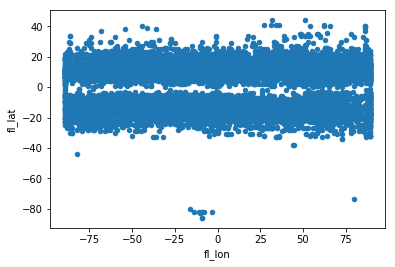

In [433]:
lfx[~myseries.isna()].plot(kind='scatter', x='fl_lon', y='fl_lat')

In [434]:
lfx[myseries.isna()].to_csv('no ar flares.csv')

Text(0.5,1,'AIA flares')

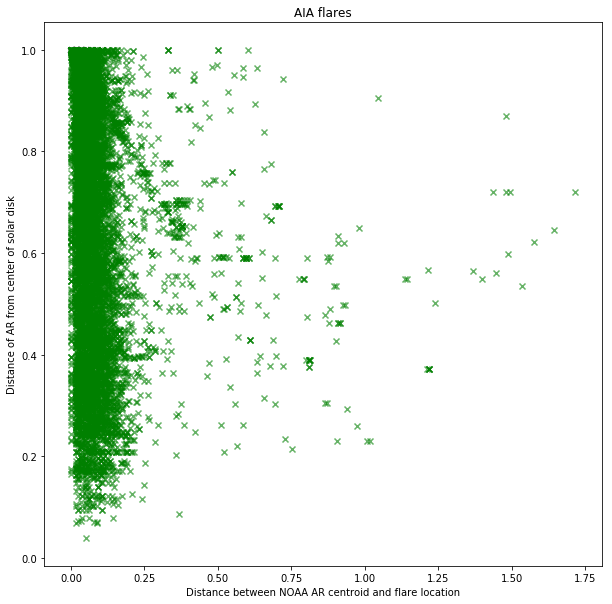

In [441]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(x=myseries, y = myseries2, marker='x', color='green', alpha=0.6)
plt.xlabel("Distance between NOAA AR centroid and flare location")
plt.ylabel("Distance of AR from center of solar disk")
plt.title('AIA flares')

Text(0.5,0,'Distance between NOAA AR centroid and flare location')

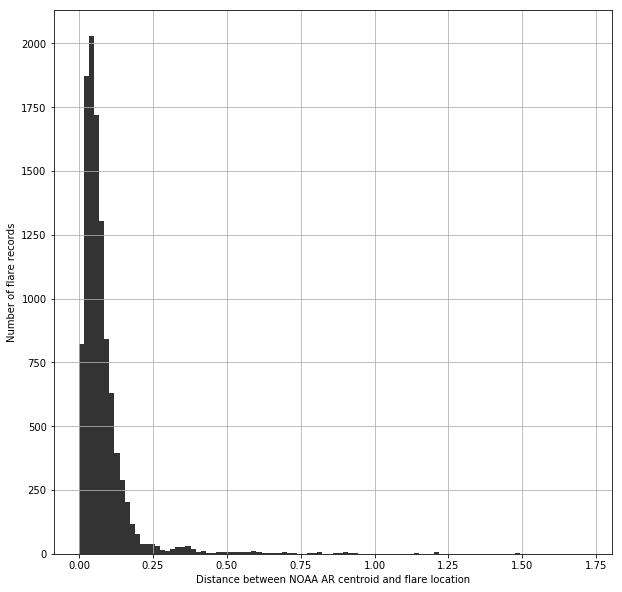

In [444]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))

myseries.hist(bins=100, color='k', alpha=0.8)
plt.ylabel('Number of flare records')
plt.xlabel('Distance between NOAA AR centroid and flare location')

In [425]:
# lfx[lfx['dist_to_ar'] > 0.3]